In [6]:
!pip install -q transformers


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
from PIL import Image
from pathlib import Path
from IPython.display import display

# Replace this path with the folder containing your images
image_dir = Path("/teamspace/studios/this_studio/images")
image_paths = sorted(image_dir.glob("*.jpg")) + sorted(image_dir.glob("*.png"))

images = [Image.open(path).convert("RGB") for path in image_paths]
image_paths

[PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 223446.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 223454.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 223503.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224133.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224141.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224154.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224210.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224221.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224230.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224238.png'),
 PosixPath('/teamspace/studios/this_studio/images/Screenshot 2026-06-02 224251.png'),
 PosixPath('/teamspace/studios/this_studio/images/Scre

In [9]:
!pip install "numpy<2" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 115.7 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
# calling the processor is equivalent to calling the feature extractor
pixel_values = processor(images, return_tensors="pt").pixel_values
print(pixel_values.shape)

torch.Size([12, 3, 384, 384])


In [9]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


1. Screenshot 2026-06-02 223446.png


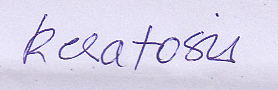

keratosis
----------------------------------------
2. Screenshot 2026-06-02 223454.png


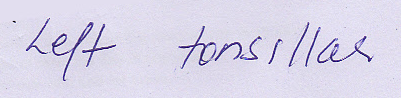

" Left tonsiller .
----------------------------------------
3. Screenshot 2026-06-02 223503.png


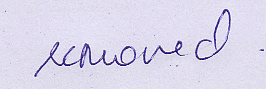

removed .
----------------------------------------
4. Screenshot 2026-06-02 224133.png


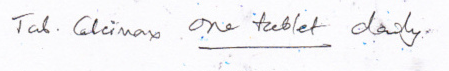

Tah. Gheimans once tablet closely .
----------------------------------------
5. Screenshot 2026-06-02 224141.png


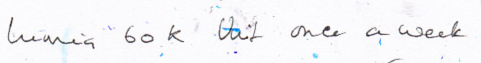

Lumsack that once a week
----------------------------------------
6. Screenshot 2026-06-02 224154.png


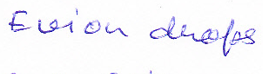

Eusion chiefs .
----------------------------------------
7. Screenshot 2026-06-02 224210.png


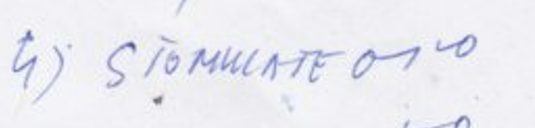

by storm-micro-
----------------------------------------
8. Screenshot 2026-06-02 224221.png


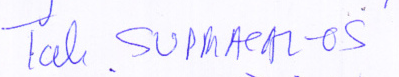

Tal summons . "
----------------------------------------
9. Screenshot 2026-06-02 224230.png


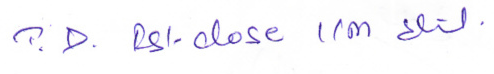

R.D. R.L.close 1 (M. Seal .
----------------------------------------
10. Screenshot 2026-06-02 224238.png


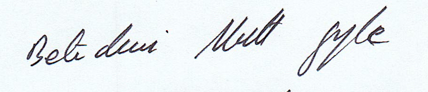

belodini Multi style .
----------------------------------------
11. Screenshot 2026-06-02 224251.png


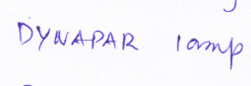

dynapar comp
----------------------------------------
12. Screenshot 2026-06-02 224312.png


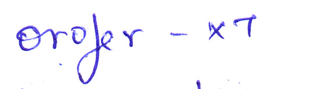

groper - x.t.
----------------------------------------


In [10]:
generated_ids = model.generate(pixel_values)
generated_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
for idx, (path, img, text) in enumerate(zip(image_paths, images, generated_texts), start=1):
    print(f"{idx}. {path.name}")
    display(img)
    print(text)
    print("----------------------------------------")